Hola **Georgina**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

# PROYECTO FINAL - ANÁLISIS DE DATOS 

## PARTE 1: **PROYECTO TELECOMUNICACIONES** 

## 1.  Descripción del Proyecto, Objetivo y Preguntas de Negocio

- **Descripción:**
El servicio de telefonía virtual CallMeMaybe está desarrollando una nueva función que brindará a los y las supervisoras información sobre los operadores menos eficaces. Se considera que un operador es ineficaz si tiene una gran cantidad de llamadas entrantes perdidas (internas y externas), un tiempo de espera prolongado para las llamadas entrantes, y un número reducido de llamadas salientes.

- **Objetivo general:** 
Analizar los datos del servicio CallMeMaybe para detectar patrones de ineficacia en operadores telefónicos.
  
**Preguntas de Negocio:**

1. ¿Cuáles son los operadores con mayor índice de ineficacia y qué características los distinguen de los más eficaces?

2. ¿Cómo varía la tasa de llamadas perdidas o realizadas según la dirección (entrante, saliente, interna) y cuáles presentan más oportunidades de mejora?

3. ¿En qué periodos de tiempo (días, meses) se presentan caídas en el número de llamadas, en el volumen de llamdas perdidas y la duración?

4. ¿De qué manera se asocia el tipo de plan tarifario con la eficacia de los operadores que atienden a esos clientes?

5. ¿Cómo se distribuye la carga de trabajo entre operadores (número total de llamadas) y qué impacto parece tener esta distribución en su nivel de ineficacia?

## 2. Lectura de Datos

- Importación y revisión inicial de los datasets `telecom_dataset_us.csv` y `telecom_clients_us.csv` para asegurar su correcta carga y visualización general de las variables y tipos de datos.

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [128]:
#Dataset que contiene info de llamadas 
df_calls = pd.read_csv("telecom_dataset_new.csv")
df_calls.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [129]:
#Dataset que contiene info de clientes
df_clients = pd.read_csv("telecom_clients.csv")
df_clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [130]:
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [131]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


## 3. Preprocesamiento

#### Unificación de formatos de fechas y tipos de datos

En el dataset df_calls es necesario cambiar el tipo de datos:
+ *object* de la columna "date" a *datetime*.
+ *float* de la columna "operator_id" a *int*.

In [132]:
df_calls["date"] = pd.to_datetime(df_calls["date"])
print(df_calls["date"].dtypes)
display(df_calls.head())

datetime64[ns, pytz.FixedOffset(180)]


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [133]:
df_calls["operator_id"] = df_calls["operator_id"].astype("Int64")
print(df_calls["operator_id"].dtypes)
display(df_calls.head())

Int64


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,<NA>,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25


En el dataset df_clients es necesario cambiar el tipo de datos:
+ *object* de la columna "date_start" a *datetime*.

In [134]:
df_clients["date_start"] = pd.to_datetime(df_clients["date_start"])
print(df_clients["date_start"].dtypes)
display(df_clients.head())

datetime64[ns]


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


#### Identificación y Eliminación de duplicados

**Dataset df_calls**

In [135]:
#Identificar duplicados
print("-- ANÁLISIS DE DUPLICADOS --")
print(f"Total de filas: {len(df_calls)}")
print(f"Filas totalmente duplicadas: {df_calls.duplicated().sum()}")
print(f"Porcentaje de duplicados: {(df_calls.duplicated().sum() / len(df_calls)) * 100:.2f}%")

# Mostrar ejemplos de duplicados
print("\n-- EJEMPLOS DE FILAS DUPLICADAS --")
duplicated_calls = df_calls[df_calls.duplicated(keep=False)]
duplicated_calls.head(8)

-- ANÁLISIS DE DUPLICADOS --
Total de filas: 53902
Filas totalmente duplicadas: 4900
Porcentaje de duplicados: 9.09%

-- EJEMPLOS DE FILAS DUPLICADAS --


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
6,166377,2019-08-05 00:00:00+03:00,out,False,880020,True,8,0,50
8,166377,2019-08-05 00:00:00+03:00,out,False,880020,True,8,0,50
27,166377,2019-08-12 00:00:00+03:00,in,False,<NA>,True,2,0,34
28,166377,2019-08-12 00:00:00+03:00,in,False,<NA>,True,2,0,34
38,166377,2019-08-14 00:00:00+03:00,in,False,<NA>,True,1,0,3
43,166377,2019-08-14 00:00:00+03:00,out,False,880026,False,10,1567,1654
44,166377,2019-08-14 00:00:00+03:00,out,False,880026,False,10,1567,1654
45,166377,2019-08-14 00:00:00+03:00,in,False,<NA>,True,1,0,3


Se identificaron 4,900 filas totalmente duplicadas (9% de los datos) lo cual podría deberse a un error del sistema que podría sesgar el análisis de eficiencia de operadores, por lo tanto serán eliminados.

In [136]:
#Eliminar duplicados
df_calls = df_calls.drop_duplicates()

#Comprobar que ya no hay duplicados
print(f"Filas totalmente duplicadas: {df_calls.duplicated().sum()}")

Filas totalmente duplicadas: 0


**Dataset - df_clients**

In [137]:
#Identificar duplicados 
print(f"Filas duplicadas: {df_clients.duplicated().sum()}")

Filas duplicadas: 0


No se encontraron filas totalmente duplicadas en el dataset df_clients.

#### Detección de valores ausentes o inconsistentes

**Dataset - df_calls**

In [138]:
#Identificar valores NaN 
df_calls.isna().sum()

user_id                   0
date                      0
direction                 0
internal                110
operator_id            7456
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

Se identificaron valores ausentes en el dataset df_calls:

+ 110 en la columna "internal"
+ 7,456 en la columna "operator_id" 

In [139]:
#Identificar valores NaN en la columna internal
internal_nan = df_calls[df_calls["internal"].isna()]
internal_nan.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
1007,166405,2019-09-18 00:00:00+03:00,in,NaN,<NA>,True,1,0,59
1090,166405,2019-10-01 00:00:00+03:00,in,NaN,<NA>,True,1,0,1
1864,166406,2019-08-20 00:00:00+03:00,in,NaN,<NA>,True,1,0,36
1924,166406,2019-09-02 00:00:00+03:00,in,NaN,879898,False,1,2,9
6210,166541,2019-09-26 00:00:00+03:00,in,NaN,908960,False,1,393,423


In [140]:
internal_values= df_calls["internal"].value_counts()
internal_values

False    43239
True      5653
Name: internal, dtype: int64

+ Al imprimir los valores de la columna "internal", se puede observar que los valores True o False indican si la llamada se hizo de manera interna o no. 

+ Dado que existen valores NaN en esta columna, serán sustituídos por el string "Unknown" que indicaría que no se conoce si la llamada corresponde a cualquiera de esos dos valores y nos ayudaría a darle claridad al dataset y a la interpretación de resultados.

In [141]:
#Sustituir valores NaN con "Unknown"
df_calls["internal"] = df_calls["internal"].fillna("Unknown")

#Verificar que la sustitución es correcta
df_calls["internal"].value_counts()

False      43239
True        5653
Unknown      110
Name: internal, dtype: int64

**Identificar valores NaN en la columna operator_id**

In [142]:
nan_operator = df_calls[df_calls["operator_id"].isna()]
display(nan_operator.head())
print()
print("- ESTADÍSTICAS DEL GRUPO DE OPERADORES SIN ID ASIGNADO")
nan_operator.describe()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,<NA>,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,<NA>,True,6,0,35
9,166377,2019-08-06 00:00:00+03:00,in,False,<NA>,True,4,0,62
17,166377,2019-08-07 00:00:00+03:00,in,False,<NA>,True,2,0,24
27,166377,2019-08-12 00:00:00+03:00,in,False,<NA>,True,2,0,34



- ESTADÍSTICAS DEL GRUPO DE OPERADORES SIN ID ASIGNADO


,user_id,operator_id,calls_count,call_duration,total_call_duration
count,7456.000000,0,7456.000000,7456.000000,7456.000000
mean,167259.123793,<NA>,14.024142,66.749598,236.959496
std,586.842979,<NA>,81.785240,945.349645,1265.307052
min,166377.000000,<NA>,1.000000,0.000000,0.000000
25%,166782.000000,<NA>,1.000000,0.000000,7.000000
50%,167125.000000,<NA>,2.000000,0.000000,35.000000
75%,167727.000000,<NA>,7.000000,0.000000,115.000000
max,168606.000000,<NA>,2168.000000,26175.000000,42667.000000


In [143]:
print("Valores de llamadas perdidas:")
print(nan_operator["is_missed_call"].value_counts())
print()
print("Valores de dirección de llamada:")
print(nan_operator["direction"].value_counts())

Valores de llamadas perdidas:
True     7343
False     113
Name: is_missed_call, dtype: int64

Valores de dirección de llamada:
in     7270
out     186
Name: direction, dtype: int64


In [144]:
print("Operador sin ID con el máximo conteo de llamadas")
display(nan_operator[nan_operator["calls_count"]== 2168.0])

Operador sin ID con el máximo conteo de llamadas


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
37070,167626,2019-10-07 00:00:00+03:00,in,False,<NA>,True,2168,0,2361


+ En la columna "operator_id" se puede observar que los 7,456 valores NaN corresponden al número de id de operadores que por alguna razón no fueron asignados. 

+ Este grupo de operadores sin id serán identificados con el número 0 que se interpretará como un grupo sin operador asignado.

+ Al observar las estadísticas de este grupo se puede observar que la mayoría de las llamadas son perdidas (7,343), el 75% de las llamadas tienen una duración de 0 minutos (no contestadas) y en su mayoría son llamadas recibidas (7,270).

+ También se observa que hay registros con un conteo de llamadas elevado (2,168 llamadas) pero con una duración de 0 minutos, lo que podría indicar que ese operador recibió 2,168 intentos pero no fueron atendidos, ya sea por fallas técnicas del sistema, falta de disponibilidad del operador o tratarse de demasiadas llamadas simultáneas.

In [145]:
#Verificar que el id "0" no haya sido asignado previamente
print(len(df_calls[df_calls["operator_id"] == 0]))

0


In [146]:
#Sustituir los valores NaN por 0
df_calls["operator_id"] = df_calls["operator_id"].fillna(0)

#Verificar que la sustitución es correcta
operators_0 = df_calls[df_calls["operator_id"]== 0]
display(operators_0.head())
print(f"Número de registros con operadores id '0': {len(operators_0)}")

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,0,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,0,True,6,0,35
9,166377,2019-08-06 00:00:00+03:00,in,False,0,True,4,0,62
17,166377,2019-08-07 00:00:00+03:00,in,False,0,True,2,0,24
27,166377,2019-08-12 00:00:00+03:00,in,False,0,True,2,0,34


Número de registros con operadores id '0': 7456


**Dataset - clients**

In [147]:
#Identificar valores NaN
df_clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

No se encontraron valores ausentes en el dataset df_clients

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien realizado el análisis inicial y el tratamiento de los dataset previo a su exploración, siempre hay que buscar tener la mejor calidad posible en tus datos
</div>

#### Integración de ambos datasets mediante claves relevantes.

In [148]:
#Unión de ambos datasets mediante "user_id"
calls_clients = df_calls.merge(df_clients, on= "user_id")
display(calls_clients.head())

#Verificar nuevamente que no hay valores nulos o ausentes 
print("Valores NaN:", calls_clients.isna().sum())
print()
print("Valores duplicados:", calls_clients.duplicated().sum())

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
0,166377,2019-08-04 00:00:00+03:00,in,False,0,True,2,0,4,B,2019-08-01
1,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5,B,2019-08-01
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1,B,2019-08-01
3,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18,B,2019-08-01
4,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25,B,2019-08-01


Valores NaN: user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
tariff_plan            0
date_start             0
dtype: int64

Valores duplicados: 0


## 4. Análisis Exploratorio de Datos (EDA)

#### 4.1 Exploración y resumen estadístico de variables clave

**Distribución de Usuarios y Operadores:**

In [149]:
print(f"Usuarios únicos con operador asignado: {calls_clients[calls_clients['operator_id'] != 0]['user_id'].nunique()}")
print(f"Operadores únicos: {calls_clients['operator_id'].nunique()}")
print(f"Registros sin ID (valor 0): {len(operators_0)}")
print(f"Usuarios únicos con operator_id '0': {calls_clients[calls_clients['operator_id'] == 0]['user_id'].nunique()}")
print("Total de usuarios únicos: 595")

Usuarios únicos con operador asignado: 290
Operadores únicos: 1093
Registros sin ID (valor 0): 7456
Usuarios únicos con operator_id '0': 305
Total de usuarios únicos: 595


In [150]:
calls_clients.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,49002.000000,49002.000000,49002.000000,49002.000000,49002.000000
mean,167294.892759,777067.827068,16.462777,866.282091,1156.558202
std,598.558965,329773.738555,63.604098,3775.503352,4451.473661
min,166377.000000,0.000000,1.000000,0.000000,0.000000
25%,166782.000000,890416.000000,1.000000,0.000000,46.000000
50%,167158.000000,906406.000000,4.000000,37.000000,208.000000
75%,167819.000000,929884.000000,12.000000,570.000000,901.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


**Hallazgos importantes**

1. Número de llamadas por registro:
    - Mínimo 1 y Máximo 4,817
    - El promedio fue de 16.4 llamadas 
    - El 50% de los registros reporta 4 llamadas o menos y el 75% 12 llamadas o menos.

  
2. Duración de llamada (sin contar tiempo de espera):
    - Mínimo 0 minutos y Máximo 144,395 minutos (≈2,406.5 hrs ≈ 100 días)
    - El promedio fue de 866.28 minutos (≈14.43 hrs)
    - El 25% de las llamadas duran 0 minutos, lo que podría indicar que se trata de llamadas perdidas o no conectadas adecuadamente.
    - El 50% de las llamadas duró 37 minutos o menos y el 75% de las llamadas duró 570 minutos (≈ 9.5 hrs) o menos.
    - La duración de llamada tiene una variabilidad muy alta, 3775.5 minutos (≈62.9 hrs).


3. Duración total de llamada (contando tiempo de espera):
    - Mínimo 0 minutos y Máximo 166,155 minutos (≈2,769 hrs ≈ 115 días)
    - El promedio fue de 1156.55 minutos (≈19.2 hrs)
    - El 50% de las llamadas duró 208 minutos (≈3.4 hrs) o menos y el 75% de las llamadas duró 901 minutos (≈ 15 hrs) o menos.
    - La duración total de llamada tiene una variabilidad muy alta, 4451.47 minutos (≈ 74.19 hrs).

**Problemas detectados:**

- El 50% de los regitsros de llamada reporta 4 llamadas o menos, mientras otros registros reportan miles. Esto sugiere: posible distribución ineficiente de la carga de trabajo o necesidad de rebalanceo operativo.

- Valores extremos irreales en la duración de las llamadas sugieren errores de sistema o llamadas no cerradas correctamente.

- Tiempo promedio de espera elevado: 1156.55 minutos de llamada total - 866.28 minutos sin contar tiempo de espera = 290.27 minutos de tiempo de espera (≈ 4.8 hrs).

- El 50% de los casos tiene un tiempo de llamada total ineficiente: Sólo existen 37 minutos de conversación real sin espera vs. 208 minutos (3.4 hrs) de tiempo total, lo que sugiere períodos de espera excesivamente largos (171 minutos ≈ 2.8hrs)

#### 4.2 Detectar outliers

De acuerdo al análisis de la distribución de la duración de llamada, se pudieron identificar valores que superan los tiempos de llamada lógicos, por lo cual a continuación se identificaran esos outliers para decidir si es necesario eliminarlos. 

In [151]:
def outliers_iqr(data, column_name):
    """Detecta outliers usando el método IQR"""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites para outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identificar outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    print(f"-- Outliers en {column_name}: --")
    print(f"Q1:{Q1:.2f}")
    print(f"Q3:{Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {lower_bound:.2f}")
    print(f"Límite superior: {upper_bound:.2f}")
    print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
    print(f"Valor mínimo outlier: {outliers.min():.2f}")
    print(f"Valor máximo outlier: {outliers.max():.2f}")
    
    return outliers, lower_bound, upper_bound

# Detectar outliers en call_duration
outliers_duration, lower_dur, upper_dur = outliers_iqr(
    calls_clients['call_duration'], 'call_duration')

-- Outliers en call_duration: --
Q1:0.00
Q3:570.00
IQR: 570.00
Límite inferior: -855.00
Límite superior: 1425.00
Outliers detectados: 6866 (14.01%)
Valor mínimo outlier: 1427.00
Valor máximo outlier: 144395.00


In [152]:
#Crear tabla de outliers 
outliers_table = calls_clients[
    (calls_clients['call_duration'] < lower_dur) | 
    (calls_clients['call_duration'] > upper_dur)
].copy()
outliers_table.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
20,166377,2019-08-09 00:00:00+03:00,out,False,880028,False,17,1603,1725,B,2019-08-01
23,166377,2019-08-12 00:00:00+03:00,out,False,880028,False,20,2074,2191,B,2019-08-01
39,166377,2019-08-14 00:00:00+03:00,out,False,880028,False,18,2686,2782,B,2019-08-01
41,166377,2019-08-14 00:00:00+03:00,out,False,880026,False,10,1567,1654,B,2019-08-01
44,166377,2019-08-15 00:00:00+03:00,out,False,880028,False,19,2653,2779,B,2019-08-01


- Al identificar los outliers se puede observar que el límite superior de la duración de llamada sería de 1425.0 minutos (equivalente a 23.7 horas), lo cual es un valor razonable para una llamada, a comparación del valor máximo encontrado anteriormente de 144,396 minutos (aprox 100 días).

**Clasificación de operadores de acuerdo a la duración de llamada**

Una vez identificados los outliers, podemos utilizar esos valores para clasificar a los operadores de acuerdo a la duración de sus llamadas. Esto nos ayudará a entender mejor cómo es el comportamiento de los operadores y en quienes vale la pena realizar un análisis más profundo que no sesgue o afecte los resultados.

La clasificación se realizará de la siguiente manera:

- **Normal:** Operadores con duración de llamada de **0 a 1,424 minutos** (duración < 24hrs)

- **Alto:** Operadores con duración de llamada entre **1,425 y 9,999 minutos** (23.7 horas - 6.9 días)

- **Extremo:** Operadores con duración de llamada mayor a **10,000 minutos** (> 7 días)

In [153]:
# Categorizar
calls_clients['duration_category'] = pd.cut(
    calls_clients['call_duration'], 
    bins=[-1, 1425, 10000, float('inf')], 
    labels=['Normal', 'Alto', 'Extremo']
)

print("Distribución de duración de llamada")
calls_clients["duration_category"].value_counts()

Distribución de duración de llamada


Normal     42136
Alto        6342
Extremo      524
Name: duration_category, dtype: int64

- Se identificaron **6,342 llamadas con duración *Alta* + 524 llamadas con duración *Extrema***, lo cual da un total de 6,866 llamadas que corresponden a los outliers.

- Al identificar aquellas llamadas que entran dentro de lo *Normal* se puede proceder a filtrar el dataset para sólo incluir los datos que no tienen valores extremadamente altos o ilógicos. 

##### Analizar la eficiencia con datos de duración de llamada "Normal"

Al categorizar las llamadas de acuerdo a su duración se puedieron identificar aquellas que entran dentro del rango "Normal", es decir con duración de 0 a 1,425 minutos (utilizando el método Q1/Q3 +/- 1.5 * IQR).

A continuación se realizará el análisis de eficiencia de operadores utilizando los datos que entran dentro del rango de normalidad, para evitar que las métricas de eficiencia se encuentren sesgadas y cuenten con poca validez.

In [154]:
# Filtrar solo datos normales para análisis principal
normal_calls = calls_clients[calls_clients['duration_category'] == 'Normal']

display(normal_calls.head())

print(f" - Total de llamadas: {len(calls_clients):,}")
print(f" - Llamadas normales: {len(normal_calls):,}")
print(f" - Porcentaje de datos normales: {len(normal_calls)/len(calls_clients)*100:.1f}%")
print(" - Número de operadores únicos:", normal_calls["operator_id"].nunique())

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start,duration_category
0,166377,2019-08-04 00:00:00+03:00,in,False,0,True,2,0,4,B,2019-08-01,Normal
1,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5,B,2019-08-01,Normal
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1,B,2019-08-01,Normal
3,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18,B,2019-08-01,Normal
4,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25,B,2019-08-01,Normal


 - Total de llamadas: 49,002
 - Llamadas normales: 42,136
 - Porcentaje de datos normales: 86.0%
 - Número de operadores únicos: 1091


**Estadísticas descriptivas y visualización de distribución de la duración de llamadas**

In [155]:
normal_calls.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,42136.000000,42136.000000,42136.000000,42136.000000,42136.000000
mean,167288.274184,755558.046469,11.279096,185.342178,397.773472
std,588.086354,349313.577806,56.170368,324.488185,1014.961000
min,166377.000000,0.000000,1.000000,0.000000,0.000000
25%,166812.000000,890402.000000,1.000000,0.000000,36.000000
50%,167158.000000,906396.000000,3.000000,0.000000,138.000000
75%,167799.000000,928888.000000,8.000000,226.000000,479.000000
max,168606.000000,973286.000000,4817.000000,1425.000000,45312.000000


**Hallazgos importantes de las llamadas Normales:**

+ Número de registros de llamadas:
    - Mínimo 1 y Máximo 4,817
    - Promedio de 11.2 llamadas
    - El 50% reporta 3 o menos llamadas
    - El 75% reporta 8 o menos llamadas.


+ Duración de llamada (sin tiempo de espera):
    - Mínimo 0 min y Máximo 1,425 min (≈ 23.75 horas)
    - Promedio de 185.3 min (≈ 3 horas)
    - El 50% de las llamadas dura 0 minutos
    - El 75% de las llamadas dura 226 min (≈ 3.7 horas) o menos.

+ Duración de llamada total (con tiempo de espera):
    - Mínimo 0 minutos y Máximo 45,312 min (≈ 755.2 horas)
    - Promedio de 397.7 min (≈ 6.6 horas)
    - El 50% de las llamadas dura 138 minutos (≈ 2.3 horas) o menos
    - El 75% de las llamadas dura 479 minutos (≈ 7.9 horas) o menos.

+ Tiempo de espera:
    - Promedio de llamada total - promedio de llamada sin tiempo de espera (397.7 min - 185.3 min = 212.4 min)
    - Tiempo de espera promedio aproximado de 3.5 hrs

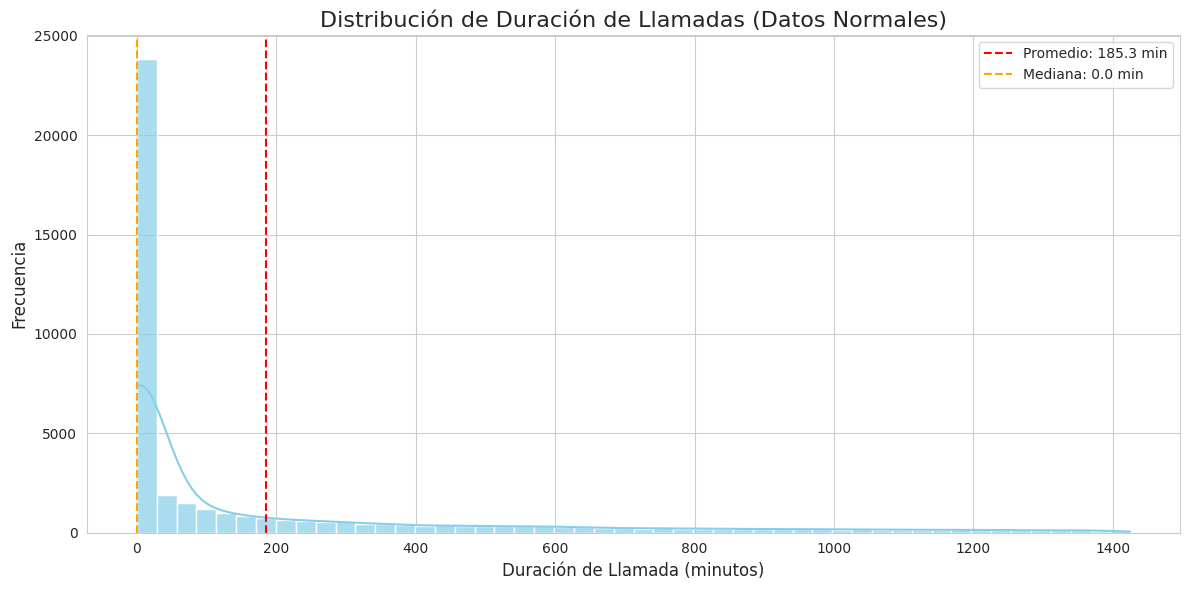

In [156]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Crear histograma con curva de densidad
sns.histplot(data=normal_calls, x='call_duration', bins=50, kde=True, 
             color='skyblue', alpha=0.7)

# Personalizar el gráfico
plt.title('Distribución de Duración de Llamadas (Datos Normales)', 
          fontsize=16)
plt.xlabel('Duración de Llamada (minutos)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Agregar estadísticas en el gráfico
mean_duration = normal_calls['call_duration'].mean()
median_duration = normal_calls['call_duration'].median()

plt.axvline(mean_duration, color='red', linestyle='--', 
           label=f'Promedio: {mean_duration:.1f} min')
plt.axvline(median_duration, color='orange', linestyle='--', 
           label=f'Mediana: {median_duration:.1f} min')

plt.legend()
plt.tight_layout()
plt.show()

- El gráfico anterior nos muestra que de acuerdo a la duración de llamada (sin tiempo de espera), los datos se encuentran concentrados entre los 0 y 185.3 minutos (3 horas).

- El hecho de que la mediana se encuentre en el valor 0 puede sugerir que el 50% de las llamadas se reportan como perdidas, lo cual nos habla de un indicador de ineficiencia que vale la pena analizar más a fondo.

- La dispersión observada en el eje de las duraciones permite evaluar si el rango actual de tiempos está dentro de lo esperado para los objetivos del servicio y detectar si se requiere ajustar el proceso para reducir variabilidad en la duración de las llamadas.

#### 4.3 Definición de métricas claras de ineficacia (llamadas perdidas, tiempo promedio de espera, llamadas salientes)

Para analizar de manera correcta las métricas de eficiencia por operador, se tomarán en cuenta aquellos registros con un operador asigando, es decir con 'operator_id' diferente de 0, ya que hay que recordar que el operator_id 0 corresponde a un grupo de registros sin ID pero que no corresponde a un operador en específico, sino que pueden ser varios operadores diferentes.

El análisis de operadores con ID '0' se realizará aparte para saber si hay algún patrón importante que indagar a fondo.

In [195]:
# Análisis principal: Solo operadores reales (sin ID 0)
real_operators = normal_calls[normal_calls['operator_id'] != 0].copy()

print("--ANÁLISIS DE OPERADORES REALES (SIN ID 0) --")
print(f"Total de registros con operadores reales: {len(real_operators)}")
print("Total de operadores únicos", real_operators['operator_id'].nunique())

--ANÁLISIS DE OPERADORES REALES (SIN ID 0) --
Total de registros con operadores reales: 34734
Total de operadores únicos 1090


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien hecho el análisis de cada gráfica y resultado, esto deja un proceso de análisis súper claro y se comunica muy bien el mensaje a transmitir con las gráficas.
</div>

**Cálculo de métricas de eficiencia para llamadas con operador asignado**

In [196]:
# Calcular métricas de eficiencia por operador
efficiency_metrics = real_operators.groupby('operator_id').agg({
    'is_missed_call': 'sum',                   # Total de llamadas perdidas
    'call_duration': 'mean',                   # Promedio de duración (sin espera)
    'total_call_duration': 'mean',               # Tiempo total promedio (incluye espera)
    'calls_count': 'sum'                         # Total de llamadas manejadas
}).round(2)

# Renombrar columnas
efficiency_metrics.columns = [
    'total_missed_calls', 
    'avg_call_duration',
    'avg_total_duration', 'total_calls']

#Calcular % de llamadas perdidas
efficiency_metrics['missed_calls_%'] = (efficiency_metrics['total_missed_calls']/ efficiency_metrics['total_calls']*100
).round(2)

# Calcular tiempo de espera promedio
efficiency_metrics['avg_wait_time'] = (
    efficiency_metrics['avg_total_duration'] - efficiency_metrics['avg_call_duration']
).round(2)

print("MÉTRICAS DE EFICIENCIA")
print()
display(efficiency_metrics.head())

MÉTRICAS DE EFICIENCIA



,total_missed_calls,avg_call_duration,avg_total_duration,total_calls,missed_calls_%,avg_wait_time
operator_id,,,,,,
879896,47,177.09,255.60,477,9.85,78.51
879898,89,88.09,420.19,2658,3.35,332.10
880020,6,112.25,126.25,45,13.33,14.00
880022,29,184.58,239.22,194,14.95,54.64
880026,87,138.57,251.71,862,10.09,113.14


In [159]:
efficiency_metrics.describe()

,total_missed_calls,avg_call_duration,avg_total_duration,total_calls,missed_calls_%,avg_wait_time
count,1090.000000,1090.000000,1090.000000,1090.000000,1090.000000,1090.000000
mean,12.944954,158.845835,362.313917,340.893578,11.340890,203.468083
std,18.402566,137.586879,529.920094,1319.135511,16.855289,531.251040
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,49.625000,105.250000,10.000000,1.620000,22.285000
50%,5.000000,141.965000,239.795000,56.500000,6.670000,42.000000
75%,18.000000,236.677500,416.920000,310.750000,13.330000,124.350000
max,119.000000,1306.000000,8205.410000,24513.000000,100.000000,8194.170000


**Hallazgos importantes**

1. **Total de llamadas por operador:**
   
- Promedio: 340.8
- El 50% de operadores reporta 56.5 llamadas
- El 75% de operadores reporta 310.7 llamadas
- Existen casos extremos con más de 20,000 llamadas

2. **Porcentaje de llamadas perdidas por operador:**

- Promedio: 11.3%
- El 75% de operadores reporta 13.3% o menos llamadas perdidas
- Existen operadores con el 100% de llamadas perdidas

3. **Tiempo de espera por operador:**

- Promedio: 1090 minutos
- El 75% de los operadores reporta un tiempo de 124.3 minutos o menos
- Existen operadores con tiempos de espera mayores a 5,000 minutos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Perfecto, los criterios para identificar el desempeño de los operadores quedó súper claro y está basado totalmente en los datos análizados lo cual demuestra un gran dominio y capacidad de análisis
</div>

**Cálculo de métricas de eficiencia para llamadas sin operador asignado**

In [160]:
cero_operators= normal_calls[normal_calls['operator_id'] == 0].copy()

print("--ANÁLISIS DE OPERADORES CON ID 0 ) --")
print(f"Total de registros con operadores reales: {len(cero_operators)}")
print("Total de operadores únicos", cero_operators['operator_id'].nunique())
print()

# Estadísticas descriptivas sin sesgo del ID 0
print("ESTADÍSTICAS DESCRIPTIVAS - OPERADORES SIN ID:")
display(cero_operators.describe())

--ANÁLISIS DE OPERADORES CON ID 0 ) --
Total de registros con operadores reales: 7402
Total de operadores únicos 1

ESTADÍSTICAS DESCRIPTIVAS - OPERADORES SIN ID:


,user_id,operator_id,calls_count,call_duration,total_call_duration
count,7402.000000,7402.0,7402.000000,7402.000000,7402.000000
mean,167251.880438,0.0,14.007295,2.427722,172.995542
std,582.796894,0.0,82.075036,42.724549,845.781709
min,166377.000000,0.0,1.000000,0.000000,0.000000
25%,166782.000000,0.0,1.000000,0.000000,7.000000
50%,167123.000000,0.0,2.000000,0.000000,34.000000
75%,167716.000000,0.0,6.000000,0.000000,112.000000
max,168606.000000,0.0,2168.000000,1290.000000,42667.000000


In [161]:
# Calcular métricas de eficiencia por operador
cero_op_eff_metrics = cero_operators.groupby('operator_id').agg({
    'is_missed_call': 'sum',                   # Total de llamadas perdidas
    'call_duration': 'mean',                   # Promedio de duración (sin espera)
    'total_call_duration': 'mean',               # Tiempo total promedio (incluye espera)
    'calls_count': 'sum'                         # Total de llamadas manejadas
}).round(2)

# Renombrar columnas
cero_op_eff_metrics.columns = [
    'total_missed_calls', 
    'avg_call_duration',
    'avg_total_duration', 'total_calls']

#Calcular % de llamadas perdidas
cero_op_eff_metrics['missed_calls_%'] = (cero_op_eff_metrics['total_missed_calls']/ cero_op_eff_metrics['total_calls']*100
).round(2)

# Calcular tiempo de espera promedio
cero_op_eff_metrics['avg_wait_time'] = (
    cero_op_eff_metrics['avg_total_duration'] - cero_op_eff_metrics['avg_call_duration']
).round(2)

print("MÉTRICAS DE EFICIENCIA")
print()
display(cero_op_eff_metrics)

MÉTRICAS DE EFICIENCIA



,total_missed_calls,avg_call_duration,avg_total_duration,total_calls,missed_calls_%,avg_wait_time
operator_id,,,,,,
0,7343,2.43,173.0,103682,7.08,170.57


**Identificar operadores con menor cantidad de llamadas salientes**

In [162]:
#Agrupar operadores y total de llamadas
calls_data = real_operators.groupby('operator_id').agg({
    'calls_count': 'sum'  # Total de llamadas por operador (in y out)
}).reset_index()

calls_data.columns=['operator_id' ,'total_calls']

# Obtener solo las llamadas salientes
out_calls = real_operators[real_operators['direction'] == 'out']
outbound_summary = out_calls.groupby('operator_id')['calls_count'].sum().reset_index()
outbound_summary.columns = ['operator_id', 'outbound_calls']

# Combinar ambas métricas
outbound_operators = calls_data.merge(
    outbound_summary, 
    on='operator_id', 
    how='left'
).fillna(0)

# Calcular porcentaje
outbound_operators['outbound_%'] = (
    outbound_operators['outbound_calls'] / outbound_operators['total_calls'] * 100
).round(2)

#Contabilizar operadores con 0 llamadas salientes
zero_calls = outbound_operators[outbound_operators['outbound_calls']== 0.0]

print("Total de operadores únicos que realizaron llamadas salientes:", len(outbound_operators))
print("Total de operadores con 0 llamadas salientes:", len(zero_calls))
print(f"Porcentaje de operadores que no realizaron llamadas: {len(zero_calls)/len(outbound_operators)*100:.2f}%")
print()
print("Operadores con porcentaje de llamadas salientes:")
outbound_operators= outbound_operators.sort_values('outbound_%')
display(outbound_operators.head(10))

Total de operadores únicos que realizaron llamadas salientes: 1090
Total de operadores con 0 llamadas salientes: 210
Porcentaje de operadores que no realizaron llamadas: 19.27%

Operadores con porcentaje de llamadas salientes:


,operator_id,total_calls,outbound_calls,outbound_%
1089,973286,2,0.0,0.0
835,944808,108,0.0,0.0
591,930242,4,0.0,0.0
592,930264,4,0.0,0.0
196,901350,92,0.0,0.0
198,901498,5,0.0,0.0
202,901734,28,0.0,0.0
829,944564,2,0.0,0.0
206,901894,30,0.0,0.0
825,944310,3,0.0,0.0


In [163]:
outbound_operators['outbound_calls'].describe()

count     1090.000000
mean       304.533945
std       1288.955891
min          0.000000
25%          2.000000
50%         30.000000
75%        251.750000
max      23781.000000
Name: outbound_calls, dtype: float64

**Hallazgos importantes**

- Del total de los 1090 operadores únicos que realizaron llamadas *out*, 881 operadores realizó 1 llamada o más y 210 operadores tuvieron 0 llamadas (lo que representa el 19.25%).
- En promedio se realizaron 304.5 llamadas *out*.
- El 50% de los operadores realizó 30 llamadas o menos, mientras que el 75% de los operadores realizó 250 llamadas o menos.
- Se identificó un operador excepcional que realizó 2,3781 llamadas (muy por encima de la media).

**Combinar todas las métricas de ineficiencia**

In [164]:
# Combinar métricas de eficiencia con llamadas salientes
inefficiency_metrics = efficiency_metrics.merge(
    outbound_operators[['operator_id','outbound_calls', 'outbound_%']], on= 'operator_id', how='left'
)

# Llenar valores NaN con 0 para operadores sin llamadas salientes
inefficiency_metrics['outbound_calls'] = inefficiency_metrics['outbound_calls'].fillna(0)
inefficiency_metrics['outbound_%'] = inefficiency_metrics['outbound_%'].fillna(0)


print("MÉTRICAS COMPLETAS DE INEFICIENCIA")
inefficiency_metrics

MÉTRICAS COMPLETAS DE INEFICIENCIA


,operator_id,total_missed_calls,avg_call_duration,avg_total_duration,total_calls,missed_calls_%,avg_wait_time,outbound_calls,outbound_%
0,879896,47,177.09,255.60,477,9.85,78.51,419.0,87.84
1,879898,89,88.09,420.19,2658,3.35,332.10,2554.0,96.09
2,880020,6,112.25,126.25,45,13.33,14.00,38.0,84.44
3,880022,29,184.58,239.22,194,14.95,54.64,186.0,95.88
4,880026,87,138.57,251.71,862,10.09,113.14,838.0,97.22
...,...,...,...,...,...,...,...,...,...
1085,972410,2,0.00,521.00,37,5.41,521.00,37.0,100.00
1086,972412,2,40.00,242.33,26,7.69,202.33,25.0,96.15
1087,972460,3,174.00,262.57,51,5.88,88.57,50.0,98.04
1088,973120,1,2.50,12.50,3,33.33,10.00,3.0,100.00


#### 4.4 Identificar al top 10 de los operadores que presenten mayores indicadores de ineficacia

- Se definirá un índice de ineficacia que combina tres dimensiones: porcentaje de llamadas perdidas, tiempo promedio de espera y proporción de llamadas salientes.

- Primero se estandarizarán las tres métrica mediante z-score y después se le asignará un peso a cada una dependiendo qué tanto influye en el índice de ineficacia.

In [165]:
cols = ['missed_calls_%', 'avg_wait_time', 'outbound_%']

#Estandarizar (z-score) por operador 
for c in cols:
    inefficiency_metrics[f'z_{c}'] = (inefficiency_metrics[c] - inefficiency_metrics[c].mean()) / inefficiency_metrics[c].std()

# Pesos de cada métrica
w_missed   = 0.4
w_wait     = 0.4
w_outbound = 0.2

#Score de ineficiencia:
#    más missed_calls_%  → peor  (+)
#    más avg_wait_time   → peor  (+)
#    más outbound_%      → mejor (−)
inefficiency_metrics['ineff_score'] = (
    w_missed * inefficiency_metrics['z_missed_calls_%'] +
    w_wait * inefficiency_metrics['z_avg_wait_time'] -
    w_outbound * inefficiency_metrics['z_outbound_%']
)

**Interpretación del Score Final:**
- Score alto (+): Operador INEFICIENTE
- Score bajo (-): Operador EFICIENTE
- Score ≈ 0: Operador promedio

In [166]:
print("TOP 10 OPERADORES MÁS INEFICACES")
top_10_worst = inefficiency_metrics.nlargest(10, 'ineff_score')[
    ['operator_id', 'missed_calls_%', 'avg_wait_time', 'outbound_%', 'ineff_score']
]
display(top_10_worst)


# Estadísticas del grupo más ineficiente
print(f"\n- ESTADÍSTICAS DEL TOP 10 MÁS INEFICAZ:")
print(f"Promedio de llamadas perdidas: {top_10_worst['missed_calls_%'].mean():.1f}%")
print(f"Promedio de tiempo de espera: {top_10_worst['avg_wait_time'].mean():.1f} minutos")
print(f"Promedio de llamadas salientes: {top_10_worst['outbound_%'].mean():.1f}%")

TOP 10 OPERADORES MÁS INEFICACES


,operator_id,missed_calls_%,avg_wait_time,outbound_%,ineff_score
582,929428,0.17,8194.17,100.00,5.574068
550,925922,0.32,5972.65,98.91,3.910519
29,885890,0.41,5059.33,97.01,3.234674
28,885876,0.48,3939.64,97.30,2.391797
317,908640,0.26,3806.54,100.00,2.272583
581,929426,0.49,3534.36,100.00,2.073106
447,919364,0.78,3518.48,100.00,2.068031
616,932246,100.00,60.00,100.00,1.818636
696,937770,100.00,37.00,100.00,1.801319
160,899076,100.00,23.50,100.00,1.791154



- ESTADÍSTICAS DEL TOP 10 MÁS INEFICAZ:
Promedio de llamadas perdidas: 30.3%
Promedio de tiempo de espera: 3414.6 minutos
Promedio de llamadas salientes: 99.3%


**Categorizar a todos los operadores de acuerdo al score de ineficiencia**

Los operadores serán categorizados de acuerdo a su nivel de ineficiencia, utilizando los percentiles 75 y 25 para identificar a los grupos con valores extremos.

In [167]:
p75 = inefficiency_metrics['ineff_score'].quantile(0.75)
p25 = inefficiency_metrics['ineff_score'].quantile(0.25)

def ineff_level(score):
    if score >= p75:
        return 'Alto'
    elif score >= p25:
        return 'Medio'
    else:
        return 'Bajo'

inefficiency_metrics['ineff_level'] = inefficiency_metrics['ineff_score'].apply(ineff_level)
display(inefficiency_metrics[['operator_id', 'ineff_score', 'ineff_level']])

,operator_id,ineff_score,ineff_level
0,879896,-0.244768,Bajo
1,879898,-0.250180,Bajo
2,880020,-0.193407,Medio
3,880022,-0.182735,Medio
4,880026,-0.260860,Bajo
...,...,...,...
1085,972410,-0.079014,Medio
1086,972412,-0.245201,Bajo
1087,972460,-0.383453,Bajo
1088,973120,0.198815,Alto


In [168]:
inefficiency_metrics["ineff_level"].value_counts()

Medio    544
Bajo     273
Alto     273
Name: ineff_level, dtype: int64

Los resultados anteriores muestran la distribución de operadores según su nivel de ineficiencia. Aquellos con score:

+ "Alto" son los que deberían priorizarse para intervención (≥ percentil 75).
+ "Medio" son los que su desempeño es relativamente bueno y sólo requieren monitoreo o segumiento (entre percentil 25 y 75).
+ "Bajo" son relativamente eficientes (< percentil 25).

#### 4.5 Identificar operadores EFICACES

Un operador eficaz debe tener:

- Menor número de llamadas perdidas (menor missed_calls_%)
- Menor tiempo de espera (menor avg_wait_time)
- Mayor cantidad de llamadas salientes (mayor outbound_%)

In [169]:
# Crear score de eficacia (inverso al de ineficiencia)
efficiency_metrics = inefficiency_metrics.copy()
efficiency_metrics['efficiency_score'] = -efficiency_metrics['ineff_score']

# Ordenar por score de eficiencia (mayor = más eficaz)
top_efficient = efficiency_metrics.nlargest(10, 'efficiency_score')[
    ['operator_id', 'missed_calls_%', 'avg_wait_time', 'outbound_%', 'efficiency_score']
]

print("TOP 10 OPERADORES MÁS EFICACES")
display(top_efficient)
# Estadísticas del grupo más ineficiente
print(f"\n- ESTADÍSTICAS DEL TOP 10 MÁS EFICAZ:")
print(f"Promedio de llamadas perdidas: {top_efficient['missed_calls_%'].mean():.1f}%")
print(f"Promedio de tiempo de espera: {top_efficient['avg_wait_time'].mean():.1f} minutos")
print(f"Promedio de llamadas salientes: {top_efficient['outbound_%'].mean():.1f}%")

TOP 10 OPERADORES MÁS EFICACES


,operator_id,missed_calls_%,avg_wait_time,outbound_%,efficiency_score
1026,960666,0.0,3.0,100.0,0.597424
603,930692,0.0,5.0,100.0,0.595918
983,955086,0.0,6.0,100.0,0.595165
985,955094,0.0,8.0,100.0,0.593659
16,883898,0.0,10.0,100.0,0.592153
250,905470,0.0,10.0,100.0,0.592153
807,941816,0.0,10.0,100.0,0.592153
55,890234,0.0,12.0,100.0,0.590647
679,937428,0.0,12.0,100.0,0.590647
414,917890,0.0,13.0,100.0,0.589894



- ESTADÍSTICAS DEL TOP 10 MÁS EFICAZ:
Promedio de llamadas perdidas: 0.0%
Promedio de tiempo de espera: 8.9 minutos
Promedio de llamadas salientes: 100.0%


- Se puede observar que los 10 operadores más eficaces son aquellos que tienen 0% de llamadas perdidas, muy poco tiempo de espera (un promedio de entre 3 y 13 minutos), y el 100% de sus llamadas son *out*.

#### 4.6 Análisis por dirección de llamada (entrante, saliente, interna).

In [170]:
direction_analysis = normal_calls.groupby('direction').agg({
    'is_missed_call': 'sum',
    'call_duration': 'mean',
    'total_call_duration': 'mean',
    'calls_count': 'sum'
}).round(2)

# Renombrar columnas para mayor claridad
direction_analysis.columns = [
    'missed_calls', 'avg_duration', 'avg_total_duration', 'total_calls'
]

# Calcular tiempo de espera promedio y porcentaje de llamadas perdidas respecto al total
direction_analysis['avg_wait_time'] = (
    direction_analysis['avg_total_duration'] - direction_analysis['avg_duration']
).round(2)

direction_analysis['%_missed_calls'] = (direction_analysis['missed_calls']/direction_analysis['total_calls']*100).round(2)

print("ANÁLISIS POR DIRECCIÓN DE LLAMADA")
display(direction_analysis)

ANÁLISIS POR DIRECCIÓN DE LLAMADA


,missed_calls,avg_duration,avg_total_duration,total_calls,avg_wait_time,%_missed_calls
direction,,,,,,
in,7887,197.13,299.96,143089,102.83,5.51
out,13566,176.45,471.57,332167,295.12,4.08


**Hallazgos importantes**

- Se realizan más llamadas *out* 332,167 vs 143,089 *in*.
- Existe mayor porcentaje de llamadas perdidas en las *in* 5.51% vs 4.08% en las *out*.
- La duración promedio es mayor en las *in* 197.13 min vs 176.45 en las *out*.
- El tiempo de espera es mayor en las *out* 295.1 min vs 102.8 min en las *in*.

**Análisis cruzado operador vs dirección**

In [171]:
# Calcular el porcentaje de llamadas por dirección para cada operador

direction_calls = normal_calls.groupby(['operator_id', 'direction']).size().unstack(fill_value=0)

# Calcular porcentajes
direction_percentages = direction_calls.div(direction_calls.sum(axis=1), axis=0) * 100
direction_percentages = direction_percentages.round(1)

print("Porcentaje de llamadas por dirección para cada operador:")
display(direction_percentages)

# Identificar operadores especializados (>80% en una dirección)
specialized_operators = {}
for direction in ['in', 'out']:
    if direction in direction_percentages.columns:
        specialized = direction_percentages[direction_percentages[direction] > 80]
        specialized_operators[direction] = specialized
        print(f"\nOperadores especializados en '{direction}': {len(specialized)}")


Porcentaje de llamadas por dirección para cada operador:


direction,in,out
operator_id,,
0,97.8,2.2
879896,19.8,80.2
879898,35.2,64.8
880020,35.0,65.0
880022,11.6,88.4
...,...,...
972410,0.0,100.0
972412,33.3,66.7
972460,14.3,85.7



Operadores especializados en 'in': 232

Operadores especializados en 'out': 451


- 232 operadores se especializan en llamadas entrantes (> 80% de sus llamadas son 'in')
- 451 operadores se especializan en llamadas salientes (> 80% de sus llamadas son 'out')
- 408 NO especializados (con llamadas totales poco significativas) o mixtos, que tienen una distribución más equilibrada entre llamadas entrantes y salientes (Llamadas 'in' y 'out' entre 20% y 80%)

#### 4.7 Análisis de Tasas por Tipo de Llamada (Internal)

In [172]:
# Explorar la relación entre 'internal' y 'direction'
print("ANÁLISIS DE LLAMADAS POR TIPO (INTERNAL)")
internal_direction = normal_calls.groupby(['internal', 'direction']).size().unstack(fill_value=0)
print("Distribución de llamadas por tipo interno y dirección:")
display(internal_direction)

# Calcular porcentajes
internal_direction_pct = internal_direction.div(internal_direction.sum(axis=1), axis=0) * 100
print("\nPorcentajes por tipo interno:")
display(internal_direction_pct.round(1))

ANÁLISIS DE LLAMADAS POR TIPO (INTERNAL)
Distribución de llamadas por tipo interno y dirección:


direction,in,out
internal,,
False,17345,19058
True,667,4956
Unknown,108,2



Porcentajes por tipo interno:


direction,in,out
internal,,
False,47.6,52.4
True,11.9,88.1
Unknown,98.2,1.8


- De todas las llamadas internas que se realizaron, el 88.1% fueron de tipo *out* vs 11.9% de tipo *in*.
- De todas las llamadas externas que se realizaron, el 52.4% fueron de tipo *out* vs 47.6% de tipo *in*.
- De todas las llamadas donde no se conoce si fue externa o interna, el 98.2% fue de tipo *in* vs 1.8% de tipo *out*.
- Lo anterior sugiere que existe un mayor balance entre llamadas *in* y *out* que son externas vs las llamadas internas donde hay mayor predominancia de tipo *out*.
- Se sugiriría monitorear con mayor atención las llamadas de tipo *in* ya que tienen un alto porcentaje de llamadas donde no se conoce si fueron internas o externas.

In [173]:
# Análisis detallado por tipo de llamada (internal)
internal_analysis = normal_calls.groupby(['internal', 'direction']).agg({
    'is_missed_call': 'sum',
    'call_duration': 'mean',
    'total_call_duration': 'mean',
    'calls_count': 'sum'
}).round(2)

# Renombrar columnas
internal_analysis.columns = [
    'missed_calls', 'avg_duration', 'avg_total_duration', 'total_calls'
]

# Calcular tiempo de espera
internal_analysis['avg_wait_time'] = (
    internal_analysis['avg_total_duration'] - internal_analysis['avg_duration']
).round(2)

print("MÉTRICAS POR TIPO DE LLAMADA")
display(internal_analysis)

MÉTRICAS POR TIPO DE LLAMADA


missed_calls  avg_duration  avg_total_duration  \
internal direction                                                   
False    in                 7533        203.00              308.83   
         out               11142        197.37              563.93   
True     in                  300         66.05              104.99   
         out                2422         96.04              116.54   
Unknown  in                   54         64.43               80.55   
         out                   2          0.00              144.50   

                    total_calls  avg_wait_time  
internal direction                              
False    in              141296         105.83  
         out             319340         366.56  
True     in                1574          38.94  
         out              12821          20.50  
Unknown  in                 219          16.12  
         out                  6         144.50

**Hallazgos importantes**

- Se registraron más llamadas perdidas en las llamadas externas de tipo *out* (11,142 llamadas)
- Para las llamadas internas, se registraron más llamadas perdidas de tipo *out* (2,422 llamadas)
- Se registraron sólo 54 llamadas perdidas, para aquellas en donde no se conoce si es interna o externa.
- Se observó mayor duración de llamada en las externas de tipo *in* (203 minutos) y en las llamadas externas de tipo *out* (197.3 minutos).
- Se observó mayor tiempo de espera en las llamadas externas de tipo *out* (366.5 minutos) y en las llamadas *Unknown* de tipo *out* (144.5 minutos).

#### 4.8 Evaluar el comportamiento de las llamadas por fecha (número y duración de llamadas)

In [174]:
# Preparar datos para análisis temporal
real_operators.copy()
real_operators['date_only'] = real_operators['date'].dt.date
real_operators['day_of_week'] = real_operators['date'].dt.day_name()

print("ANÁLISIS TEMPORAL DE LLAMADAS:")
print(f"Período de análisis: {real_operators['date'].min()} a {real_operators['date'].max()}")
print(f"Total de días únicos: {real_operators['date_only'].nunique()}")

ANÁLISIS TEMPORAL DE LLAMADAS:
Período de análisis: 2019-08-02 00:00:00+03:00 a 2019-11-28 00:00:00+03:00
Total de días únicos: 118


In [175]:
# Análisis diario del número de llamadas
daily_calls = real_operators.groupby('date_only').agg({
    'calls_count': 'sum',
    'is_missed_call': 'sum',
    'call_duration': 'mean',
    'total_call_duration': 'mean'
}).round(2)

# Renombrar columnas
daily_calls.columns = [
    'total_calls', 'missed_calls', 'avg_duration', 'avg_total_duration'
]

# Calcular tiempo de espera diario
daily_calls['avg_wait_time'] = (
    daily_calls['avg_total_duration'] - daily_calls['avg_duration']
).round(2)

print("* MÉTRICAS DIARIAS: ")
print(f"Promedio de llamadas por día: {daily_calls['total_calls'].mean():.0f}")
print(f"Día con más llamadas: {daily_calls['total_calls'].max():,}")
print(f"Día con menos llamadas: {daily_calls['total_calls'].min():,}")

display(daily_calls.head())

* MÉTRICAS DIARIAS: 
Promedio de llamadas por día: 3149
Día con más llamadas: 10,766
Día con menos llamadas: 4


,total_calls,missed_calls,avg_duration,avg_total_duration,avg_wait_time
date_only,,,,,
2019-08-02,19,3,27.17,81.17,54.00
2019-08-03,27,2,160.33,237.33,77.00
2019-08-04,4,2,38.00,49.67,11.67
2019-08-05,55,6,28.91,117.82,88.91
2019-08-06,67,7,182.15,252.69,70.54


In [176]:
daily_calls.describe()

,total_calls,missed_calls,avg_duration,avg_total_duration,avg_wait_time
count,118.000000,118.000000,118.000000,118.000000,118.000000
mean,3148.932203,119.576271,200.401525,463.929407,263.527881
std,2518.423319,100.590938,52.025250,133.545734,128.552988
min,4.000000,2.000000,27.170000,49.670000,11.670000
25%,943.250000,31.500000,182.570000,412.980000,175.122500
50%,2311.000000,86.000000,213.410000,449.590000,237.050000
75%,5431.000000,196.000000,237.150000,518.017500,317.725000
max,10766.000000,333.000000,275.480000,856.760000,627.810000


**Hallazgos importantes:**

+ Llamadas perdidas diarias:
    - Promedio: 180
    - Mínimo 2 y Máximo 452 llamadas.

+ Duración diaria:
    - Promedio: 156.2 minutos (2.6 hrs)
    - Mínimo 0 y Máximo 227 minutos (3.7 hrs)

+ Tiempo de espera diario:
    - Promedio: 225.9 minutos (3.7 hrs)
    - Mínimo 9.7 y Máximo 482.8 minutos (8 hrs)

**Identificar días exactos con mayor y menor número de llamadas totales**

In [177]:
# Encontrar el índice de la fila con máximo y mín total_calls
max_calls_idx = daily_calls['total_calls'].idxmax()
min_calls_idx = daily_calls['total_calls'].idxmin()

# Obtener filas correspondientes
max_calls_row = daily_calls.loc[max_calls_idx]
min_calls_row = daily_calls.loc[min_calls_idx]

In [178]:
# Crear un DataFrame con ambas filas para comparación
extreme_days = daily_calls.loc[[max_calls_idx, min_calls_idx]]
max_date = pd.to_datetime(max_calls_idx)
min_date = pd.to_datetime(min_calls_idx)

print("COMPARACIÓN: DÍAS CON MÁXIMO Y MÍNIMO TOTAL_CALLS")
display(extreme_days)
print()

print(f"Día con más llamadas: {max_date.strftime('%A, %B %d, %Y')}")
print(f"Día con menos llamadas: {min_date.strftime('%A, %B %d, %Y')}")

COMPARACIÓN: DÍAS CON MÁXIMO Y MÍNIMO TOTAL_CALLS


,total_calls,missed_calls,avg_duration,avg_total_duration,avg_wait_time
date_only,,,,,
2019-11-11,10766,282,229.51,403.23,173.72
2019-08-04,4,2,38.00,49.67,11.67



Día con más llamadas: Monday, November 11, 2019
Día con menos llamadas: Sunday, August 04, 2019


**Identificar el día de la semana con mayores y menores llamadas perdidas**

In [179]:
# Agrupar por día de la semana y sumar llamadas perdidas
weekly_missed_calls = real_operators.groupby('day_of_week').agg({
    'is_missed_call': 'sum',
    'calls_count': 'sum'
}).round(2)

# Renombrar columnas para claridad
weekly_missed_calls.columns = ['total_missed_calls', 'total_calls']

# Calcular porcentaje de llamadas perdidas
weekly_missed_calls['missed_%'] = (
    weekly_missed_calls['total_missed_calls'] / 
    weekly_missed_calls['total_calls'] * 100
).round(2)

print("LLAMADAS PERDIDAS POR DÍA DE LA SEMANA:")
display(weekly_missed_calls.sort_values(by= 'missed_%', ascending= False))

LLAMADAS PERDIDAS POR DÍA DE LA SEMANA:


,total_missed_calls,total_calls,missed_%
day_of_week,,,
Wednesday,2654,66412,4.00
Thursday,2742,69968,3.92
Friday,2430,62716,3.87
Tuesday,2630,68738,3.83
Monday,2392,63798,3.75
Saturday,736,23248,3.17
Sunday,526,16694,3.15


- El porcentaje de llamadas perdidas por día de la semana se mantiene entre 4.32% y 5.03%.
- Los días con menor % de llamadas perdidas son Sábado y Lunes.
- Los días con mayor % de llamadas perdidas son Domingo y Miércoles.

**Identificar el mes con mayor número de llamadas perdidas**

In [180]:
# Crear columna de mes a partir del índice de daily_calls
daily_calls['month'] = pd.to_datetime(daily_calls.index).month
daily_calls['month_name'] = pd.to_datetime(daily_calls.index).strftime('%B')

# Agrupar por mes
monthly_calls = daily_calls.groupby(['month', 'month_name']).agg({
    'total_calls': 'sum',
    'missed_calls': 'sum',
    'avg_duration': 'mean',
    'avg_total_duration': 'mean',
    'avg_wait_time': 'mean'
}).round(2)

In [181]:
# Calcular porcentaje de llamadas perdidas por mes
monthly_calls['missed_%'] = (
    monthly_calls['missed_calls'] / monthly_calls['total_calls'] * 100
).round(1)

# Crear resumen comparativo
print("COMPARACIÓN MENSUAL COMPLETA:")
comparison = monthly_calls[['total_calls', 'missed_calls', 'missed_%', 'avg_duration','avg_wait_time']]
display(comparison)

print(f"Mes con más llamadas totales: {monthly_calls['total_calls'].idxmax()[1]}")
print(f"Mes con mayor % de llamadas perdidas: {monthly_calls['missed_%'].idxmax()[1]}")
print(f"Mes con mayor tiempo de espera: {monthly_calls['avg_wait_time'].idxmax()[1]}")

COMPARACIÓN MENSUAL COMPLETA:


,,total_calls,missed_calls,missed_%,avg_duration,avg_wait_time
month,month_name,,,,,
8,August,15583,568,3.6,145.46,320.88
9,September,64415,2464,3.8,194.75,279.17
10,October,142369,4913,3.5,222.20,269.59
11,November,149207,6165,4.1,239.23,180.66


Mes con más llamadas totales: November
Mes con mayor % de llamadas perdidas: November
Mes con mayor tiempo de espera: August


- De Agosto a Octubre el número de llamadas totales aumentó (+ 169,213 llamdas) y el % de llamadas perdidas disminuyó (-1.5%), sin embargo, durante el mes de Noviembre el porcentaje de llamadas perdidas tuvo un ligero aumento (+ 0.7%) pero el tiempo de espera disminuyó pasando de 235.2 minutos en Agosto a 183.1 en Noviembre (diferencia de 52.1 minutos).

#### 4.9 Correlacionar el plan tarifario de los clientes con el desempeño de sus operadores, para entender el impacto de la inversión del cliente en la calidad del servicio recibido.

In [182]:
# Verificar las columnas relacionadas con clientes
print(f"\nPlanes tarifarios únicos: {real_operators['tariff_plan'].unique()}")
print(f"Número de usuarios únicos: {real_operators['user_id'].nunique()}")


Planes tarifarios únicos: ['B' 'C' 'A']
Número de usuarios únicos: 290


In [183]:
# Merge con operadores más eficaces
efficient_clients = real_operators.merge(
    top_efficient[['operator_id']], 
    on='operator_id', 
    how='inner'
)

print("ANÁLISIS DE CLIENTES ATENDIDOS POR OPERADORES MÁS EFICACES:")
print(f"Usuarios únicos atendidos: {efficient_clients['user_id'].nunique()}")

# Análisis por plan tarifario
efficient_tariff = efficient_clients.groupby('tariff_plan').agg({
    'user_id': 'unique',
    'calls_count': 'sum',
    'is_missed_call': 'sum',
    'call_duration': 'mean'
}).round(2)

efficient_tariff.columns = ['usuarios_unicos', 'total_llamadas', 'llamadas_perdidas', 'duracion_promedio']
efficient_tariff['%_llamadas_perdidas'] = (
    efficient_tariff['llamadas_perdidas'] / efficient_tariff['total_llamadas'] * 100
).round(2)

print("\nDISTRIBUCIÓN POR PLAN TARIFARIO - OPERADORES EFICACES:")
display(efficient_tariff)

ANÁLISIS DE CLIENTES ATENDIDOS POR OPERADORES MÁS EFICACES:
Usuarios únicos atendidos: 8

DISTRIBUCIÓN POR PLAN TARIFARIO - OPERADORES EFICACES:


,usuarios_unicos,total_llamadas,llamadas_perdidas,duracion_promedio,%_llamadas_perdidas
tariff_plan,,,,,
B,"[166884, 167176, 167580]",5,0,288.67,0.0
C,"[166507, 166520, 166939, 167852, 168073]",20,0,42.27,0.0


- Del total de los 307 clientes, 8 son antendidos por los operadores más eficaces, de los cuales la mayoría corresponde al plan tarifario "C".

In [184]:
# Merge con operadores menos eficaces
worst_clients = real_operators.merge(
    top_10_worst[['operator_id']], 
    on='operator_id', 
    how='inner'
)

print("ANÁLISIS DE CLIENTES ATENDIDOS POR OPERADORES MENOS EFICACES:")
print(f"Usuarios únicos atendidos: {worst_clients['user_id'].nunique()}")

# Análisis por plan tarifario
worst_tariff = worst_clients.groupby('tariff_plan').agg({
    'user_id': 'unique',
    'calls_count': 'sum',
    'is_missed_call': 'sum',
    'call_duration': 'mean'
}).round(2)

worst_tariff.columns = ['usuarios_unicos', 'total_llamadas', 'llamadas_perdidas', 'duracion_promedio']
worst_tariff['%_llamadas_perdidas'] = (
    worst_tariff['llamadas_perdidas'] / worst_tariff['total_llamadas'] * 100
).round(2)

print("\nDISTRIBUCIÓN POR PLAN TARIFARIO - OPERADORES INEFICACES:")
display(worst_tariff)

ANÁLISIS DE CLIENTES ATENDIDOS POR OPERADORES MENOS EFICACES:
Usuarios únicos atendidos: 7

DISTRIBUCIÓN POR PLAN TARIFARIO - OPERADORES INEFICACES:


,usuarios_unicos,total_llamadas,llamadas_perdidas,duracion_promedio,%_llamadas_perdidas
tariff_plan,,,,,
A,"[166582, 167285, 167626, 168187]",68722,289,200.20,0.42
B,"[167012, 167183]",3,3,0.00,100.00
C,[167827],25493,63,25.59,0.25


- Del total de los 307 clientes, 7 son atendidos por los operadores menos eficaces, de los cuales la mayoría corresponde al plan tarifario "A".
- A diferencia de los clientes con operadores eficaces, estos clientes cuentan con más cantidad de llamadas y a su vez con mayor pérdida de llamadas.

## 6. Planteamiento y Pruebas de Hipótesis Estadísticas

#### Hipótesis 1: Los operadores con Alto nivel de ineficiencia tienen significativamente más llamadas perdidas que los operadores con Bajo nivel de ineficiencia.

- **H₀ (Hipótesis nula):** La media de llamadas perdidas es igual en ambos grupos.

- **H₁ (Hipótesis alternativa):** La media de llamadas perdidas es mayor en el grupo de operadores con ineficiencia Alta que los de Baja.

**Preparar datos para la prueba**

In [185]:
inefficiency_data = inefficiency_metrics.copy()
ineff_level_data = inefficiency_data[inefficiency_data['ineff_level'].isin(
    ['Alto', 'Bajo'])].copy()

ineff_level_data['ineff_level'].value_counts()

Bajo    273
Alto    273
Name: ineff_level, dtype: int64

In [186]:
#Separar los grupos
level_alto = ineff_level_data.loc[ineff_level_data['ineff_level']== 'Alto', 'total_missed_calls']
level_bajo = ineff_level_data.loc[ineff_level_data['ineff_level']== 'Bajo', 'total_missed_calls']

print(level_alto.describe())
print()
print(level_bajo.describe())

count    273.000000
mean       8.150183
std       11.873234
min        1.000000
25%        1.000000
50%        4.000000
75%       12.000000
max      115.000000
Name: total_missed_calls, dtype: float64

count    273.000000
mean      20.703297
std       23.095308
min        0.000000
25%        2.000000
50%       13.000000
75%       30.000000
max      113.000000
Name: total_missed_calls, dtype: float64


**Aplicar prueba estadística**

In [187]:
# Realizar la prueba de Mann-Whitney U
statistic, p_value = stats.mannwhitneyu(
    level_alto, 
    level_bajo, 
    alternative='greater'  # level_alto > level_bajo
)

print("PRUEBA DE MANN-WHITNEY U")
print(f"Estadístico U: {statistic}")
print(f"Valor p: {p_value:.5f}")
print(f"Nivel de significancia: 0.05")

if p_value < 0.05:
    print("RECHAZAMOS H₀: Existe diferencia significativa")
    print("Los operadores con nivel Alto tienen significativamente más llamadas perdidas")
else:
    print("NO RECHAZAMOS H₀: No hay evidencia de diferencia significativa")

PRUEBA DE MANN-WHITNEY U
Estadístico U: 25908.5
Valor p: 1.00000
Nivel de significancia: 0.05
NO RECHAZAMOS H₀: No hay evidencia de diferencia significativa


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, siempre se debe realizar pruebas estadísticas para determinar si las diferencias observadas son significativas y no se está sesgando el análisis
</div>

Se comparó el total de llamadas perdidas entre operadores con ineficiencia Alta y Baja mediante una prueba Mann-Whitney U.

La media de total_missed_calls fue 31.758242 en Alta y 19.043956 en Baja (p = 0.05).

**Dado que p > 0.05, NO se puede afirmar con evidencia estadística que los operadores en nivel de ineficiencia Alto pierden significativamente más llamadas que los de nivel Bajo.**

#### Hipótesis 2: "Los operadores con Alto nivel de ineficiencia tienen significativamente mayor tiempo de espera promedio que los operadores con Bajo nivel de ineficiencia".

- **H₀ (Hipótesis nula):** La media de tiempo de espera es igual en ambos grupos.

- **H₁ (Hipótesis alternativa):** La media de tiempo de espera es mayor en el grupo de operadores con ineficiencia Alta que los de Baja.

In [188]:
#Separar los grupos
wait_alto = ineff_level_data.loc[ineff_level_data['ineff_level']== 'Alto', 'avg_wait_time']
wait_bajo = ineff_level_data.loc[ineff_level_data['ineff_level']== 'Bajo', 'avg_wait_time']

print(wait_alto.describe())
print()
print(wait_bajo.describe())

count     273.000000
mean      511.344505
std       974.618170
min         0.000000
25%        16.130000
50%        29.880000
75%       951.860000
max      8194.170000
Name: avg_wait_time, dtype: float64

count    273.000000
mean     115.642564
std       99.918359
min        0.000000
25%       33.250000
50%       88.940000
75%      176.820000
max      455.440000
Name: avg_wait_time, dtype: float64


In [189]:

# Realizar la prueba de Mann-Whitney U
statistic, p_value = stats.mannwhitneyu(
    wait_alto, 
    wait_bajo, 
    alternative='greater'  # level_alto > level_bajo
)

print("PRUEBA DE MANN-WHITNEY U")
print(f"Estadístico U: {statistic}")
print(f"Valor p: {p_value:.5f}")
print(f"Nivel de significancia: 0.05")

if p_value < 0.05:
    print("RECHAZAMOS H₀: Existe diferencia significativa")
    print("Los operadores con nivel Alto tienen significativamente más llamadas perdidas")
else:
    print("NO RECHAZAMOS H₀: No hay evidencia de diferencia significativa")

PRUEBA DE MANN-WHITNEY U
Estadístico U: 31525.0
Valor p: 0.99908
Nivel de significancia: 0.05
NO RECHAZAMOS H₀: No hay evidencia de diferencia significativa


Se comparó el tiempo de espera promedio entre operadores con ineficiencia Alta y Baja mediante una prueba Mann-Whitney U.

La media de avg_wait_time fue 388.792051 en Alta y 128.561538 en Baja (p = 0.05).

Dado que p > 0.05, NO se puede afirmar con evidencia estadística que los operadores en nivel de ineficiencia Alto tienen significativamente más tiempo de espera que los de nivel Bajo.


#### Hipótesis 3: "Los operadores con Alta carga de trabajo tienen significativamente mayor porcentaje de llamadas perdidas que los operadores con Baja carga de trabajo".

- **H₀ (Hipótesis nula):** La media de porcentaje de llamadas es igual en ambos grupos.

- **H₁ (Hipótesis alternativa):** La media de porcentaje de llamadas es mayor en el grupo de operadores con carga Alta que los de Baja.

**Crear los grupos por carga de trabajo** 

In [190]:
#Dividir grupos por total de llamadas mediante cuartiles
calls_metrics = inefficiency_metrics.copy()

q1 = calls_metrics['total_calls'].quantile(0.25)
q3 = calls_metrics['total_calls'].quantile(0.75)

# Crear columna de grupo de carga (extremos)
def workload_group(calls):
    if calls <= q1:
        return 'Baja'
    elif calls >= q3:
        return 'Alta'
    else:
        return 'Media'

calls_metrics['workload_group'] = calls_metrics['total_calls'].apply(workload_group)
calls_metrics[['operator_id', 'workload_group']].head()

,operator_id,workload_group
0,879896,Alta
1,879898,Alta
2,880020,Media
3,880022,Media
4,880026,Alta


In [191]:
#Filtrar grupos con carga Alta y Baja
extremes= calls_metrics[calls_metrics['workload_group'].isin(['Alta', 'Baja'])].copy()
extremes['workload_group'].value_counts()

Baja    291
Alta    273
Name: workload_group, dtype: int64

**Extraer datos para aplicar prueba estadística**

In [192]:
load_alta = extremes.loc[extremes['workload_group'] == 'Alta', 'missed_calls_%']
load_baja = extremes.loc[extremes['workload_group'] == 'Baja', 'missed_calls_%']

print("ESTADÍSTICAS DESCRIPTIVAS")
print("\nAlta carga:")
print(load_alta.describe())
print("\nBaja carga:")
print(load_baja.describe())

ESTADÍSTICAS DESCRIPTIVAS

Alta carga:
count    273.000000
mean       4.632527
std        3.023044
min        0.170000
25%        2.100000
50%        3.880000
75%        6.630000
max       14.170000
Name: missed_calls_%, dtype: float64

Baja carga:
count    291.000000
mean      19.433746
std       28.702354
min        0.000000
25%        0.000000
50%        0.000000
75%       30.000000
max      100.000000
Name: missed_calls_%, dtype: float64


In [193]:
# Realizar la prueba de Mann-Whitney U
statistic, p_value = stats.mannwhitneyu(
    load_alta, 
    load_baja, 
    alternative='greater'  # level_alto > level_bajo
)

print("PRUEBA DE MANN-WHITNEY U")
print(f"Estadístico U: {statistic}")
print(f"Valor p: {p_value:.5f}")
print(f"Nivel de significancia: 0.05")

if p_value < 0.05:
    print("RECHAZAMOS H₀: Existe diferencia significativa")
    print("Los operadores con nivel Alto tienen significativamente más llamadas perdidas")
else:
    print("NO RECHAZAMOS H₀: No hay evidencia de diferencia significativa")

PRUEBA DE MANN-WHITNEY U
Estadístico U: 41967.0
Valor p: 0.12047
Nivel de significancia: 0.05
NO RECHAZAMOS H₀: No hay evidencia de diferencia significativa


Se comparó el promedio de porcentaje de llamadas perdidad entre operadores con carga de trabajo Alta y Baja mediante una prueba Mann-Whitney U.

La media de missed_calls_% fue 4.641460 en Alta y 19.433746 en Baja (p = 0.05).

**Dado que p > 0.05, NO se puede afirmar con evidencia estadística que la alta carga de trabajo se asocie con mayor porcentaje de llamadas perdidas.**

## 7. Conclusiones

1. **Hallazgos Principales sobre Ineficiencia de Operadores**

Distribución de Operadores por Nivel de Eficiencia:

- 273 operadores (25%) presentan alto nivel de ineficiencia y requieren intervención inmediata
- 544 operadores (50%) tienen nivel medio y necesitan monitoreo continuo
- 273 operadores (25%) son altamente eficientes y pueden servir como modelo

Características de Operadores Ineficaces (Top 10):

- 30.3% de llamadas perdidas vs. 0% en operadores eficaces
- Tiempo de espera promedio: 3,414 minutos (≈57 horas) vs. 9 minutos en eficaces

2. **Problemas Sistémicos Identificados**

Grupo de Operadores sin ID Asignado (ID = 0):

- 7,402 registros representan llamadas sin operador asignado
- 98.5% son llamadas perdidas (problema crítico del sistema)
- 97% son llamadas entrantes no atendidas
- Indica fallas en el sistema de asignación automática

3.**Outliers en Duración de Llamadas:**

- 14% de los datos contienen valores irreales (hasta 144,395 minutos ≈ 100 días)
- Sugiere errores del sistema o llamadas no cerradas correctamente
- Impacta negativamente las métricas de eficiencia

4. **Análisis Temporal y Operativo**

Patrones por Día de la Semana:
  
- Domingos y miércoles: Mayor porcentaje de llamadas perdidas (≈5%)
- Sábados y lunes: Mejor rendimiento (≈4.3% llamadas perdidas)

Evolución Mensual:

- Noviembre: Mes con más llamadas totales pero también mayor % de llamadas perdidas
- Agosto: Mayor tiempo de espera promedio (235 minutos)

5. **Resultados de Pruebas de Hipótesis**

Todas las hipótesis estadísticas fueron rechazadas (p > 0.05):

- Llamadas perdidas: No hay diferencia significativa entre operadores de alta y baja ineficiencia
- Tiempo de espera: No hay diferencia significativa entre grupos
- Carga de trabajo: No se asocia significativamente con llamadas perdidas

- Variables no incluidas en el análisis podrían estar influyendo más que las métricas de eficiencia o el problema podría ser más sistémico que individual.

5. **Impacto en Clientes por Plan Tarifario**

- Clientes Plan A: Mayormente atendidos por operadores ineficaces
- Clientes Plan C: Mayormente atendidos por operadores eficaces
- Diferencia en calidad de servicio según plan tarifario

## 8. Recomedaciones

1. **Rebalancear la carga y rutas de llamadas**

- Implementar reglas de distribución que limiten la concentración de grandes volúmenes en unos pocos operadores y reduzcan el uso del grupo con operator_id = 0 reasignando esas llamadas a operadores concretos.

- Revisar la configuración de colas y horarios de atención para adaptar la dotación de operadores a los periodos de mayor demanda identificados en el análisis temporal.


2. **Establecer indicadores operativos y umbrales de alerta**

- Definir KPIs por operador (porcentaje de llamadas perdidas, tiempo promedio de espera, número de llamadas atendidas) con umbrales máximos aceptables y paneles de monitoreo en tiempo real.

- Generar alertas cuando un operador supere sistemáticamente los límites definidos, activando acciones de capacitación, acompañamiento o revisión de procesos.

3. **Mejorar la calidad de datos y procesos de cierre de llamada**

- Ajustar los sistemas para garantizar el registro correcto de inicio/fin de llamadas y evitar sesiones abiertas que generan duraciones irreales.

- Establecer controles periódicos de calidad de datos (detección temprana de duplicados, IDs faltantes y outliers) para que los análisis de eficiencia futuros se basen siempre en información confiable.

4. **Análisis cualitativo complementario**

- Entrevistas con supervisores
- Revisión de procesos operativos
- Análisis de casos específicos

## 9. Presentación de resultados y dashboard
- Link Dashboard: https://public.tableau.com/shared/6P5JB8W5Z?:display_count=n&:origin=viz_share_link

In [194]:
#Presentación
from IPython.display import FileLink
FileLink('PresentacionCallMeMaybe.pdf')


/app/PresentacionCallMeMaybe.pdf

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado Georgina!** 

La presentación quedó super clara y muy profesional, la herramienta utilizada da una exposición creativa de los resultados obtenidos en tu análisis. 

Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>